# Example: GBM Net Present Value Trade Rule
In this example, we evaluate a scheduled long position using the net present value (NPV) trade rule from the lecture, with the future share price modeled by geometric Brownian motion (GBM). For a chosen firm, holding period, and benchmark rate, we compute the probability that the scaled NPV clears a target return, and then plot that probability across a range of targets.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * **Compute a terminal target probability under GBM:** Combine the scaled NPV of a long position with the lognormal GBM price to evaluate the closed-form probability that the trade clears a target return over a fixed holding period.
> * **Check the calculation with a known case:** Verify the implementation by confirming that the median return is cleared with probability one half.
> * **Read a probability-versus-target curve:** Sweep the target return, plot the exceedance probability against it, and interpret what negative and positive targets mean for a trading decision.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period. 

Let's load the `original_dataset::DataFrame` by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in the `dataset` variable.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];

Not all tickers in our dataset have the maximum number of trading days for various reasons, such as acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has the maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow;

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # check if ticker has maximum trading days
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Next, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable:

In [5]:
list_of_tickers = keys(dataset) |> collect |> sort; # list of firm "ticker" symbols in alphabetical order

Now, let's load the GBM parameters that we computed in the previous example into the `parameters_df::DataFrame` variable. Recall that the legacy `drift` column stores the mean growth rate estimate $\widehat{\bar g}$, and the `volatility` column stores $\hat{\sigma}$:

In [6]:
parameters_df = let

    # load -
    df = CSV.read(joinpath(_PATH_TO_DATA,"SAGBM-Parameters-Fall-2025.csv"), DataFrame);
    df; # return
end;

### Constants
Finally, let's set some constants we'll use later in this notebook. The comments describe the constants, their units, and permissible values:

In [7]:
TSIM = 63; # number of trading days to simulate
Δt = (1.0/252); # step size: 1 trading day in units of years
g_b = 0.05; # benchmark growth rate g_b (annualized, continuously compounded)

___

## Compute the NPV Trade Rule
In this task, we compute the target probability of the NPV trade rule for a selected firm in our dataset, assuming that the future share price follows GBM. From the lecture, for a target $\rho_{\star}>-1$, benchmark growth rate $g_b$, and holding period $T$, the probability that the scaled NPV $\rho_{T}$ clears the target is:
$$
\mathbb{P}\left(\rho_{T}>\rho_{\star}\right) = 1-\Phi\left(\frac{\ln(1+\rho_{\star}) + g_bT - \bar g\,T}{\sigma\sqrt{T}}\right)
$$
where $\bar g = \mu-\sigma^{2}/2$ is the mean growth rate (the `drift` column of the parameters file) and $\Phi(\cdot)$ is the standard normal cumulative distribution function. Let's start by selecting a firm from our dataset. You can change the value of the `selected_firm_ticker::String` variable to analyze a different firm:

In [8]:
selected_firm_ticker = "AAPL"; # test ticker symbol

Next, let's specify a target return `f₊::Float64`. This is the target $\rho_{\star}$ of the lecture; the code keeps the shorter name. We'll experiment with different values of `f₊` later to see how it affects the probability:

In [9]:
f₊ = -0.15; # target return ρ⋆ (must be > -1)

Now, let's perform a few test calculations and see what happens for different targets, e.g., `f₊ = -0.15` or `f₊ = 0.15`. What do we observe?

In [10]:
let

    # initialize -
    i = findfirst(x-> x==selected_firm_ticker, list_of_tickers); # index of the selected firm
    ĝ = parameters_df[i,:drift]; # mean growth rate estimate ḡ (legacy column name)
    σ = parameters_df[i,:volatility]; # volatility estimate σ̂
    T = TSIM * Δt; # holding period (in years)
    d = Normal(); # standard normal distribution
    m = ĝ*T; # mean of ln(S_T/S_0) under GBM: (μ - σ²/2)T = ḡT
    
    # compute the probability of clearing f₊ -
    N = log((1.0 + f₊)*exp(g_b*T)) - m; # numerator: ln(1+ρ⋆) + g_b T - ḡ T
    D = σ*sqrt(T); # denominator: σ√T
    p = 1.0 - cdf(d, N/D); # probability that ρ_T > ρ⋆
    println("For $(selected_firm_ticker) with f₊=$(f₊), the P(ρ_T > f₊) in T = $(TSIM) days is p=$(round(p,digits=4)).");
end

For AAPL with f₊=-0.15, the P(ρ_T > f₊) in T = 63 days is p=0.9638.


Before we trust the numbers, let's check the implementation against a case where we know the answer. The scaled NPV $\rho_{T}$ is a monotone function of $\ln(S_{T}/S_{0})$, whose median under GBM is $\bar g\,T$. So the target that corresponds to the median return, $\rho_{\star} = \exp(\bar g\,T - g_bT) - 1$, must be cleared with probability exactly $1/2$. Let's check:

In [11]:
let
    i = findfirst(x-> x==selected_firm_ticker, list_of_tickers);
    ĝ = parameters_df[i,:drift]; σ = parameters_df[i,:volatility]; T = TSIM*Δt;
    ρ_median = exp(ĝ*T - g_b*T) - 1.0; # target equal to the median scaled NPV
    p = 1.0 - cdf(Normal(), (log((1.0 + ρ_median)*exp(g_b*T)) - ĝ*T)/(σ*sqrt(T)));
    println("Median target ρ⋆ = $(round(ρ_median, digits=4)) gives P(ρ_T > ρ⋆) = $(p) (should be 0.5)");
    @assert isapprox(p, 0.5; atol=1e-12) "median check failed"
end

Median target ρ⋆ = 0.0494 gives P(ρ_T > ρ⋆) = 0.49999999999999967 (should be 0.5)


The check passes. Now, let's compute the target probability for a range of targets $\rho_{\star}\in[-0.2,0.4]$ (you can change this range if desired).

We'll save the results in the `P::Array{Float64,2}` variable, where rows correspond to different values of $\rho_{\star}$, the first column contains the value of $\rho_{\star}$, and the second column contains the corresponding probability:

In [12]:
P = let

    # initialize -
    i = findfirst(x-> x==selected_firm_ticker, list_of_tickers); # index of the selected firm
    ĝ = parameters_df[i,:drift]; # mean growth rate estimate ḡ (legacy column name)
    σ = parameters_df[i,:volatility]; # volatility estimate σ̂
    T = TSIM * Δt; # holding period (in years)
    d = Normal(); # standard normal distribution
    m = ĝ*T; # mean of ln(S_T/S_0) under GBM
    number_of_points = 201; # number of points in the target range

    f = range(-0.20, stop=0.40, length=number_of_points) |> collect; # range of targets ρ⋆
    P = Array{Float64,2}(undef, number_of_points, 2); # initialize

    for i ∈ eachindex(f)
        # compute the probability of clearing f[i] -
        N = log((1.0 + f[i])*exp(g_b*T)) - m; # numerator
        D = σ*sqrt(T); # denominator
        p = 1.0 - cdf(d, N/D); # probability that ρ_T > f[i]
        P[i,1] = f[i]; # target
        P[i,2] = p; # probability
    end

    P;
end;

`Unhide` the code cell below to see how we visualized the probability of clearing the target, as a function of the target $\rho_{\star}$. This curve is one minus the cumulative distribution function of $\rho_{T}$, i.e., the exceedance probability.

> __What do you observe?__ How does the probability change as we vary the target $\rho_{\star}$? For this calibration and range, when $\rho_{\star} < 0$ the probability that $\rho_{T} > \rho_{\star}$ is high: clearing a negative target means losing no more than that amount, and the event includes every break-even and profitable outcome. As $\rho_{\star}$ increases through zero, the curve passes through the probability of a positive scaled NPV, and for $\rho_{\star} \gg 0$ the probability is low, meaning a large positive return is unlikely over this holding period.

How can we use this information to make informed trading decisions?

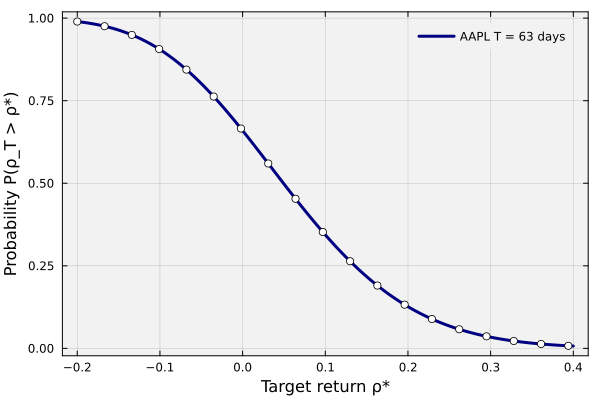

In [13]:
let

    # initialize -
    skip = 11;
    n = size(P,1);

    plot(P[:,1], P[:,2], c=:navy, lw=3, label="$(selected_firm_ticker) T = $(TSIM) days", legend=:topright);
    scatter!(P[1:skip:n,1], P[1:skip:n,2], c=:white, mec=:navy, ms=4, label="");
    xlabel!("Target return ρ*");
    ylabel!("Probability P(ρ_T > ρ*)");

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

___

## Summary
In this example, we computed the probability that a scheduled long position clears a target return under a GBM price model, checked the calculation against the median case, and plotted how the probability falls as the target rises.

> __Key Takeaways:__
>
> * **The target probability is a one-line standardization:** Under GBM the scaled NPV is a monotone function of a normal log price ratio, so the probability of clearing any target is one minus a standard normal CDF evaluated at a standardized threshold that combines the target, the benchmark rate, the mean growth rate, the volatility, and the holding period.
>
> * **A known case catches implementation errors:** The target equal to the median return must be cleared with probability one half, which is a cheap and exact check on the code.
>
> * **The probability-versus-target curve is the decision aid:** Reading across the curve gives the chance of losing no more than a stated amount, the chance of a positive scaled NPV, and the chance of a large gain, all from the same model.

The resulting probabilities provide a model-based decision aid, but their usefulness depends on the adequacy of the GBM assumptions, the parameter estimates, and the chosen target.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance.  Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___